<a href="https://colab.research.google.com/github/MaryamFagbo/FacialRecognitionAttendanceForUniversity/blob/main/Maryam_Fagbo_Experiment_Code_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Project: Smart University Identity Recognition System
**Student:** MARYAM MODUPE FAGBO / 443407050
**Course:** Machine Learning

## Deliverable 2: Experiment Code
This notebook covers pre-processing, feature extraction, data analysis (EDA), and machine learning algorithm experimentation using the Labeled Faces in the Wild (LFW) dataset.

In [ ]:
# 1. IMPORTING LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import tensorflow as tf
from tensorflow.keras import layers, models

# Setting plot style based on standard lab formats
plt.style.use('ggplot')

## 2. Data Loading and Exploratory Data Analysis (EDA)
Here we load the dataset and perform basic EDA to understand the distribution of our classes (identities) and visualize the raw data.

Downloading/Loading LFW Dataset...
Exploratory Data Analysis (EDA)
Total images (samples): 1288
Image dimensions: 50 x 37
Number of distinct identities (classes): 7


/tmp/ipykernel_2683/2256496903.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Identity', data=df_eda, order=df_eda['Identity'].value_counts().index, palette='viridis')


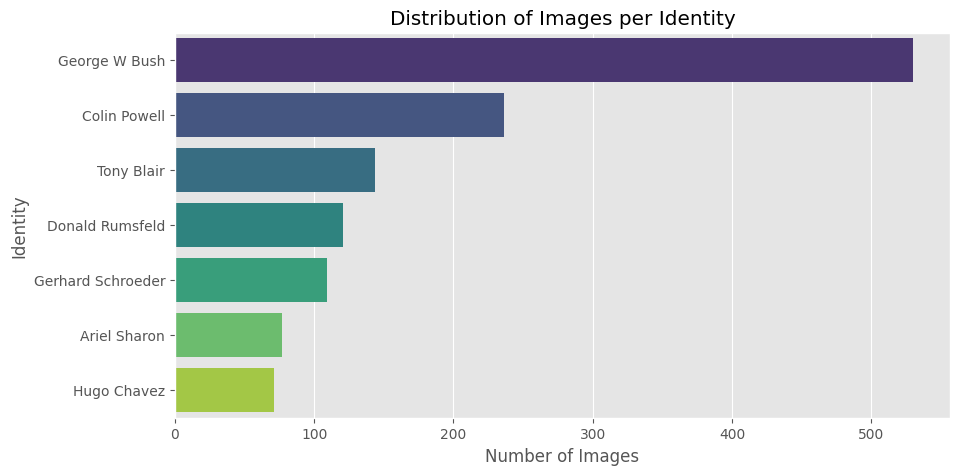

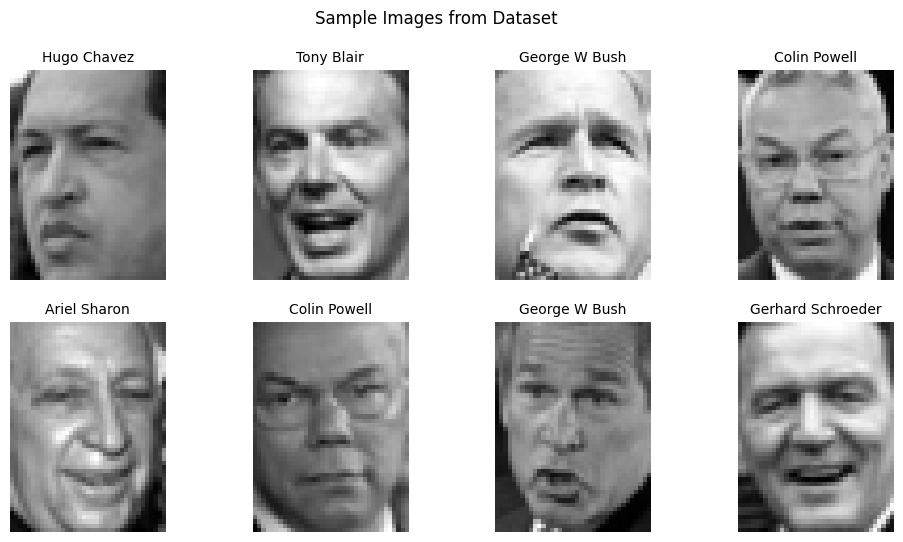

In [ ]:
# Load dataset directly from scikit-learn (mimicking a local university database)
print("Downloading/Loading LFW Dataset...")
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)

# Extract arrays
n_samples, h, w = lfw_people.images.shape
X = lfw_people.data
y = lfw_people.target
target_names = lfw_people.target_names
n_classes = target_names.shape[0]

print("===========================================")
print("Exploratory Data Analysis (EDA)")
print("===========================================")
print(f"Total images (samples): {n_samples}")
print(f"Image dimensions: {h} x {w}")
print(f"Number of distinct identities (classes): {n_classes}")

# Create a Pandas DataFrame for EDA (to match lab styles)
df_eda = pd.DataFrame({'Identity': [target_names[i] for i in y]})
plt.figure(figsize=(10, 5))
sns.countplot(y='Identity', data=df_eda, order=df_eda['Identity'].value_counts().index, palette='viridis')
plt.title("Distribution of Images per Identity")
plt.xlabel("Number of Images")
plt.show()

# Visualize a few sample faces
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(lfw_people.images[i], cmap='gray')
    ax.set_title(target_names[y[i]], fontsize=10)
    ax.axis('off')
plt.suptitle("Sample Images from Dataset")
plt.show()

## 3. Data Pre-processing & Feature Extraction
We will split the data into 70% training and 30% testing. Then, we will use Principal Component Analysis (PCA) to extract 'Eigenfaces'. This reduces the high dimensionality of the images into core features for our traditional ML models (KNN and SVM).

In [ ]:
# Train-Test Split (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Feature Extraction using PCA
n_components = 150
print(f"\nExtracting top {n_components} features using PCA...")
pca = PCA(n_components=n_components, svd_solver='randomized', whiten=True).fit(X_train)

X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print("Feature extraction complete.")

Training set size: 901 samples
Testing set size: 387 samples

Extracting top 150 features using PCA...
Feature extraction complete.


## 4. Machine Learning Experimentation
We will test three models as proposed: K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and a Convolutional Neural Network (CNN).
### Model 1: K-Nearest Neighbors (KNN)

In [ ]:
# Training KNN (similar to Lab 2)
print("Training KNN Model...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_pca, y_train)

# Predictions & Evaluation
y_pred_knn = knn_model.predict(X_test_pca)
knn_acc = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {knn_acc:.4f}")

Training KNN Model...
KNN Accuracy: 0.6072


### Model 2: Support Vector Machine (SVM)

In [ ]:
# Training SVM
print("Training SVM Model...")
svm_model = SVC(kernel='rbf', class_weight='balanced')
svm_model.fit(X_train_pca, y_train)

# Predictions & Evaluation
y_pred_svm = svm_model.predict(X_test_pca)
svm_acc = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {svm_acc:.4f}")

# Detailed Classification Report for SVM
print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=target_names))

Training SVM Model...
SVM Accuracy: 0.8191

Classification Report (SVM):
                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.56      0.71        18
     Colin Powell       0.62      0.94      0.75        69
  Donald Rumsfeld       0.84      0.62      0.71        34
    George W Bush       0.89      0.90      0.90       166
Gerhard Schroeder       0.86      0.77      0.81        31
      Hugo Chavez       1.00      0.53      0.69        19
       Tony Blair       0.93      0.74      0.82        50

         accuracy                           0.82       387
        macro avg       0.88      0.72      0.77       387
     weighted avg       0.85      0.82      0.82       387



### Model 3: Convolutional Neural Network (CNN)
For the CNN, we use the raw image data (reshaped to include the color channel) rather than the PCA features.

In [ ]:
# Reshape data for CNN (Adding channel dimension for grayscale)
X_train_cnn = X_train.reshape(-1, h, w, 1)
X_test_cnn = X_test.reshape(-1, h, w, 1)

print("Building and Training CNN Model...")
cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(h, w, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model (Using 10 epochs for speed)
history = cnn_model.fit(X_train_cnn, y_train, epochs=10, validation_data=(X_test_cnn, y_test), verbose=1)

# Predictions & Evaluation
cnn_predictions = cnn_model.predict(X_test_cnn)
y_pred_cnn = np.argmax(cnn_predictions, axis=1)
cnn_acc = accuracy_score(y_test, y_pred_cnn)
print(f"\nCNN Accuracy: {cnn_acc:.4f}")

Building and Training CNN Model...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.3885 - loss: 1.7595 - val_accuracy: 0.4289 - val_loss: 1.6198
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.4484 - loss: 1.6057 - val_accuracy: 0.4522 - val_loss: 1.5229
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.4994 - loss: 1.4464 - val_accuracy: 0.5478 - val_loss: 1.3885
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.5671 - loss: 1.2720 - val_accuracy: 0.5814 - val_loss: 1.1860
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.6349 - loss: 1.0898 - val_accuracy: 0.6460 - val_loss: 1.0647
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6903 - loss: 0.9238 - val_accuracy: 0.7442 - val_loss: 0.9437
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7714 - loss: 0.7479 - val_accuracy: 0.7416 - val_loss: 0.8373
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.8291 - loss: 0.5860 - val_accuracy: 0.7106 - val_loss: 0.

## 5. Results & Analysis Visualizations
Comparing the performance of all three models using a bar chart and visualizing the confusion matrix for our best-performing traditional model.

/tmp/ipykernel_2683/1961464675.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models_names, y=accuracies, palette='mako')


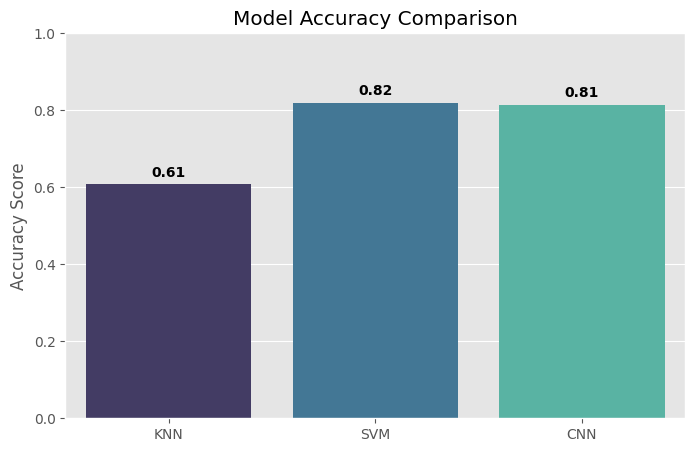

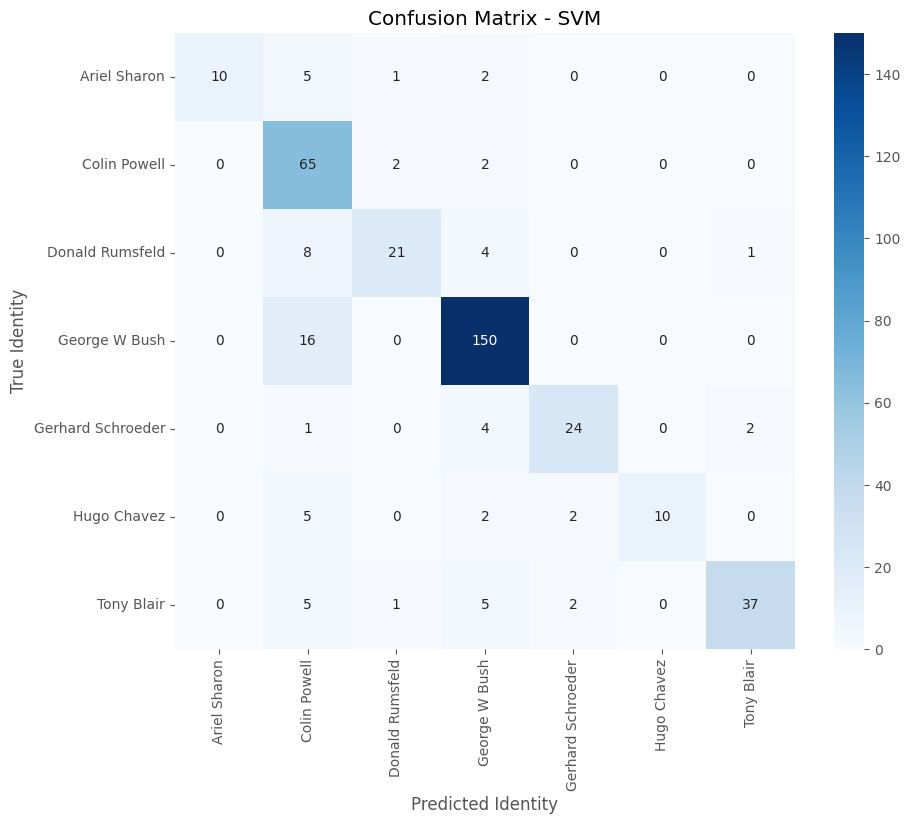

In [ ]:
# Model Comparison Plot
models_names = ['KNN', 'SVM', 'CNN']
accuracies = [knn_acc, svm_acc, cnn_acc]

plt.figure(figsize=(8, 5))
sns.barplot(x=models_names, y=accuracies, palette='mako')
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# Plotting Confusion Matrix for SVM
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - SVM')
plt.ylabel('True Identity')
plt.xlabel('Predicted Identity')
plt.show()